# Отбор признаков

In [1]:
import sys

from pathlib import Path

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.config import config

In [2]:
from init_pipeline import init_experiment
init_experiment(project_root, config)

Инициализация пропущена: /Users/romansafronenkov/Documents/Projects/uplift_modeling_pipeline/artifacts/boosting_pipeline/status.json уже существует и init=True


## Логирование

In [3]:
import os

from src.utils.logger import setup_logging

LOG_DIR = project_root / 'artifacts' / config.general.experiment_name / 'log'
os.makedirs(LOG_DIR, exist_ok=True)

LOG_FILE = LOG_DIR / 'feature_selection.txt'

_logger = setup_logging(LOG_FILE, 'feature_selection')

/Users/romansafronenkov/Documents/Projects/uplift_modeling_pipeline/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Импорты

In [4]:
# ждем пока выполнится предыдущий ноутбук
import json
import time

while True:
    with open(project_root / 'artifacts' / config.general.experiment_name / 'status.json', 'r') as f:
        status = json.load(f)
    if status['dataset']:
        _logger.info('Датасет загружен, отбираем признаки')
        break
    time.sleep(60) 

[2026-09-03 13:46:43,990] - [feature_selection] - [INFO] - Датасет загружен, отбираем признаки


In [5]:
import shutil
import copy
import json
import random
import time

import joblib

from IPython.display import clear_output, display

import pandas as pd
import numpy as np

import pyspark.sql.functions as F

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import OrdinalEncoder
from catboost import CatBoostClassifier, CatBoostError
from lightgbm import LGBMClassifier
from lightgbm.callback import early_stopping

from BorutaShap import BorutaShap
import optuna

from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
clear_output()

In [6]:
from src.preprocessing import preprocess_sdf
from src.utils.feature_selection import LGMFeatureSelection, ShapFeatureSelection, remove_null_cols, find_correlated_columns
from src.utils.feature_stability import calculate_psi
from src.utils.uplift_clf_metrics import show_results
from src.utils.optimization import metric_stability

In [7]:
if config.general.load_venv_to_spark:
    os.environ['PYSPARK_PYTHON'] = './environment/bin/python'
    os.environ['PYSPARK_DRIVER_PYTHON'] = './environment/bin/python'

In [8]:
np.random.seed(config.general.seed)
random.seed(config.general.seed)

In [9]:
from src.utils.get_spark import get_conf, get_spark

conf = get_conf()

if config.general.load_venv_to_spark:
    conf.set('spark.archives', project_root / 'venv.tar.gz#environment')

In [10]:
spark = get_spark(conf, app_name=config.general.spark_session_name)

clear_output()
spark

# Загрузка данных, препроцессинг и базовый отбор

In [11]:
_logger.info(f'Experiment name: {config.general.experiment_name}')
fs_path = project_root / 'artifacts' / config.general.experiment_name / 'feature_selection'
data_dir = project_root / 'data'
os.makedirs(fs_path, exist_ok=True)

[2026-09-03 13:47:16,920] - [feature_selection] - [INFO] - Experiment name: boosting_pipeline


In [12]:
if config.general.select_features:
    dataset = spark.read.parquet(str(data_dir / 'train_dataset.parquet'))
    dataset = dataset.drop(*config.feature_selection.drop_cols)

    len_dataset = dataset.count()
    _logger.info(f'Dataset length: {len_dataset}, dataset columns: {len(dataset.columns)}')

[2026-09-03 13:47:19,185] - [feature_selection] - [INFO] - Dataset length: 458976, dataset columns: 53


In [13]:
if config.general.select_features:
    dates_target = dataset.select(config.dataset.date_col).distinct().collect()
    dates_target = sorted([row[config.dataset.date_col] for row in dates_target])
    clear_output()
    _logger.info(f'Доступные даты:\n{dates_target}')

[2026-09-03 13:47:19,832] - [feature_selection] - [INFO] - Доступные даты:
['2025-01-01', '2025-02-01', '2025-03-01', '2025-04-01', '2025-05-01', '2025-06-01', '2025-07-01', '2025-08-01', '2025-09-01']


In [14]:
if config.general.select_features:
    columns_not_to_check = [config.dataset.date_col, config.dataset.target_col, config.dataset.treatment_col]

    _logger.info(f"Колонки {columns_not_to_check} исключены из базового отбора признаков")

    dataset_columns = dataset.columns
    _logger.info(f'Число колонок в исходном датасете: {len(dataset.columns)}')

    dataset, null_stats = remove_null_cols(dataset.select([col for col in dataset.columns if col not in columns_not_to_check]))
    _logger.info(f"Число колонок после удаления колонок с пропусками: {len(dataset.columns)}")

[2026-09-03 13:47:19,835] - [feature_selection] - [INFO] - Колонки ['date', 'target', 'treatment'] исключены из базового отбора признаков
[2026-09-03 13:47:19,835] - [feature_selection] - [INFO] - Число колонок в исходном датасете: 53


26/09/03 13:47:20 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


[2026-09-03 13:47:20,902] - [feature_selection] - [INFO] - Число колонок после удаления колонок с пропусками: 50


In [15]:
if config.general.select_features:
    _logger.info("Найдем признаки с типом decimal и преобразуем их в float")
    decimal_columns = list(filter(lambda x: 'decimal' in x[1], dataset.dtypes))
    decimal_columns = [col[0] for col in decimal_columns]
    _logger.info(f"Число decimal признаков: {len(decimal_columns)}")

    select_cols = [F.col(col).cast('float') if col in decimal_columns else col for col in dataset.columns]
    dataset = dataset.select(select_cols)

    _logger.info(f"Уникальные типы данных в датасете: {set(map(lambda x: x[1], dataset.dtypes))}")

[2026-09-03 13:47:20,906] - [feature_selection] - [INFO] - Найдем признаки с типом decimal и преобразуем их в float
[2026-09-03 13:47:20,906] - [feature_selection] - [INFO] - Число decimal признаков: 0
[2026-09-03 13:47:20,940] - [feature_selection] - [INFO] - Уникальные типы данных в датасете: {'double'}


In [16]:
if config.general.select_features:
    columns_to_check = []

    for col_name, dtype in dataset.dtypes:
        if dtype not in ('string', 'timestamp'):
            columns_to_check.append(col_name)

    columns_to_check = list(set(columns_to_check) - set(columns_not_to_check))
    _logger.info(f"Число признаков, которые будут проверяться на корреляцию: {len(columns_to_check)}")

[2026-09-03 13:47:20,942] - [feature_selection] - [INFO] - Число признаков, которые будут проверяться на корреляцию: 50


In [17]:
if config.general.select_features:
    _logger.info("Отбор признаков по корреляции")
    if len_dataset < 200000:
        check_corr_dataset = dataset.select(columns_to_check).toPandas()
    else:
        fraction = float(np.round(200000 / len_dataset, 3))
        _logger.info(f"Доля данных, которые будут использоваться для оценки корреляции: {fraction}")

        check_corr_dataset = dataset.select(columns_to_check).sample(fraction=fraction, withReplacement=False, seed=config.general.seed).toPandas()

    _logger.info(f'Shape датасета для проверки корреляции: {check_corr_dataset.shape}')

    correlated_columns, corr_stats = find_correlated_columns(check_corr_dataset)

[2026-09-03 13:47:20,945] - [feature_selection] - [INFO] - Отбор признаков по корреляции
[2026-09-03 13:47:20,946] - [feature_selection] - [INFO] - Доля данных, которые будут использоваться для оценки корреляции: 0.436
[2026-09-03 13:47:24,209] - [feature_selection] - [INFO] - Shape датасета для проверки корреляции: (200352, 50)


In [18]:
if config.general.select_features:
    features = set(dataset.columns) - set(columns_not_to_check) - correlated_columns
    _logger.info(f"Количество признаков после базового отбора: {len(features)}")

    joblib.dump(features, fs_path / 'features_after_base_prep.pkl')
    joblib.dump(null_stats, fs_path / 'null_stats.pkl')
    joblib.dump(corr_stats, fs_path / 'corr_stats.pkl')

    _logger.info(f"Признаки после базого отбора сохранены в {fs_path / 'features_after_base_prep.pkl'}")
    _logger.info(f"Статистики пропусков сохранены в {fs_path / 'null_stats.pkl'}")
    _logger.info(f"Статистики корреляции сохранены в {fs_path / 'corr_stats.pkl'}")

[2026-09-03 13:47:25,026] - [feature_selection] - [INFO] - Количество признаков после базового отбора: 43
[2026-09-03 13:47:25,029] - [feature_selection] - [INFO] - Признаки после базого отбора сохранены в /Users/romansafronenkov/Documents/Projects/uplift_modeling_pipeline/artifacts/boosting_pipeline/feature_selection/features_after_base_prep.pkl
[2026-09-03 13:47:25,029] - [feature_selection] - [INFO] - Статистики пропусков сохранены в /Users/romansafronenkov/Documents/Projects/uplift_modeling_pipeline/artifacts/boosting_pipeline/feature_selection/null_stats.pkl
[2026-09-03 13:47:25,029] - [feature_selection] - [INFO] - Статистики корреляции сохранены в /Users/romansafronenkov/Documents/Projects/uplift_modeling_pipeline/artifacts/boosting_pipeline/feature_selection/corr_stats.pkl


# Отбор признаков

In [19]:
if config.general.select_features:
    _logger.info('Подгружаем датасет заново')
    features = joblib.load(fs_path / 'features_after_base_prep.pkl')
    dataset = spark.read.parquet(str(data_dir / 'train_dataset.parquet'))

    dataset = dataset.select(list(features)+[config.dataset.date_col, config.dataset.target_col, config.dataset.treatment_col])

    dataset, dt_features, bitmask_cols = preprocess_sdf(dataset, config)
    len_dataset = dataset.count()

    _logger.info(f'Размер датасета: {len_dataset}')

[2026-09-03 13:47:25,031] - [feature_selection] - [INFO] - Подгружаем датасет заново
[2026-09-03 13:47:25,117] - [src.preprocessing] - [INFO] - Num of datetime features: 0
[2026-09-03 13:47:25,117] - [src.preprocessing] - [INFO] - Num of bitmask features: 0
[2026-09-03 13:47:25,150] - [src.preprocessing] - [INFO] - Num of decimal features: 0
[2026-09-03 13:47:25,150] - [src.preprocessing] - [INFO] - Unique datatypes in dataset: {'string', 'int', 'double'}
[2026-09-03 13:47:25,210] - [feature_selection] - [INFO] - Размер датасета: 458976


In [ ]:
if config.general.select_features:
    if len_dataset < config.feature_selection.dataset_size:
        dataset_pd_sample = dataset.toPandas()
    else:
        _logger.info('Сэмплируем датасет для отбора признаков')
        fraction = float(np.round(config.feature_selection.dataset_size / len_dataset, 3))
        _logger.info(f'Доля датасета, на которой будут отбираться признаки: {fraction}')

        # stratified sample
        dataset = dataset.withColumn('stratification_col', F.concat(
            F.col(config.dataset.target_col).cast('string'),
            F.col(config.dataset.treatment_col).cast('string'),
            F.col(config.dataset.date_col).cast('string')
        ))
        strat_count = dataset.groupby('stratification_col').count().collect()
        strat_count = {row['stratification_col']: row['count'] / len_dataset for row in strat_count}

        _logger.info(f"Stratification stats:\n{strat_count}")

        fractions = {key: fraction for key in strat_count.keys()}

        dataset_pd_sample = dataset.sampleBy(col='stratification_col', fraction=fractions, seed=config.general.seed).toPandas()

        _logger.info(f"Sample stratification stats:\n{dataset_pd_sample['stratification_col'].value_counts(normalize=True)}")
        dataset_pd_sample.drop(['stratification_col'], axis=1, inplace=True)

        _logger.info(f"Target_stats:\n{dataset_pd_sample['target'].value_counts(normalize=True)}")
        clear_output()

In [21]:
if config.general.select_features:
    _logger.info("Кодируем строковые признаки")
    def find_string_features(sdf):
        def find_str(pair):
            col, dtype = pair
            if col not in [config.dataset.date_col, config.dataset.target_col, config.dataset.treatment_col]:
                if dtype == 'string':
                    return col
        return [pair[0] for pair in list(filter(find_str, sdf.dtypes))]

    string_features = find_string_features(dataset)
    _logger.info(f'Число признаков с типом string: {len(string_features)}')

    for col in string_features:
        dataset_pd_sample[col] = dataset_pd_sample[col].astype('category')

    dataset_pd_sample_prep = dataset_pd_sample.copy()

    enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan)
    dataset_pd_sample_prep[string_features] = enc.fit_transform(dataset_pd_sample_prep[string_features])

    _logger.info(f'Типы данных в датасете: {dataset_pd_sample_prep.dtypes.unique()}')

[2026-09-03 13:47:31,719] - [feature_selection] - [INFO] - Кодируем строковые признаки
[2026-09-03 13:47:31,720] - [feature_selection] - [INFO] - Число признаков с типом string: 0
[2026-09-03 13:47:31,744] - [feature_selection] - [INFO] - Типы данных в датасете: [dtype('float64') dtype('O') dtype('int32')]


In [22]:
if config.general.select_features:
    prep_features = []
    for feat in features:
        if feat in dt_features:
            prep_features.append(feat+'_diff')
        elif feat in bitmask_cols:
            prep_features.append(feat+'_sum')
        else:
            prep_features.append(feat)

    dataset_pd_sample_prep = dataset_pd_sample_prep[
    prep_features+[config.dataset.date_col, config.dataset.target_col, config.dataset.treatment_col]
    ]

In [23]:
if config.general.select_features:
    col_stats = {}

    for col, dtype in tqdm(dataset_pd_sample.dtypes.items()):
        if col in [config.dataset.date_col, config.dataset.target_col, config.dataset.treatment_col]:
            continue

        if 'category' in str(dtype):
            col_stats[col] = float((dataset_pd_sample_prep[col] == config.feature_selection.string_na_val).mean())

        if 'float' in str(dtype) or 'int' in str(dtype):
            col_stats[col] = float((dataset_pd_sample_prep[col] == config.feature_selection.num_na_val).mean())

    _logger.info(f'Статистика пропусков:\n{col_stats}')
    clear_output()

In [24]:
spark.stop()

## Качество модели на всех признаках

[2026-09-03 13:47:33,600] - [feature_selection] - [INFO] - Обучаем модель на всех признаках
[2026-09-03 13:47:48,716] - [feature_selection] - [INFO] - Train roc_auc: 0.8336341810270814
[2026-09-03 13:47:48,737] - [feature_selection] - [INFO] - Val roc_auc: 0.7813246541696046
[2026-09-03 13:47:48,739] - [feature_selection] - [INFO] - Число признаков с 0 feature importance: 0


,Feature Id,Importances
0,treatment,9.817678
1,X_16,7.654772
2,X_41,5.573167
3,X_33,5.106596
4,X_47,4.870962
5,X_19,4.838240
6,X_3,4.811265
7,X_4,4.059376
8,X_35,3.428129
9,X_15,3.401621


[2026-09-03 13:47:49,259] - [matplotlib.category] - [INFO] - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[2026-09-03 13:47:49,262] - [matplotlib.category] - [INFO] - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[2026-09-03 13:47:49,299] - [matplotlib.category] - [INFO] - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[2026-09-03 13:47:49,304] - [matplotlib.category] - [INFO] - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotti

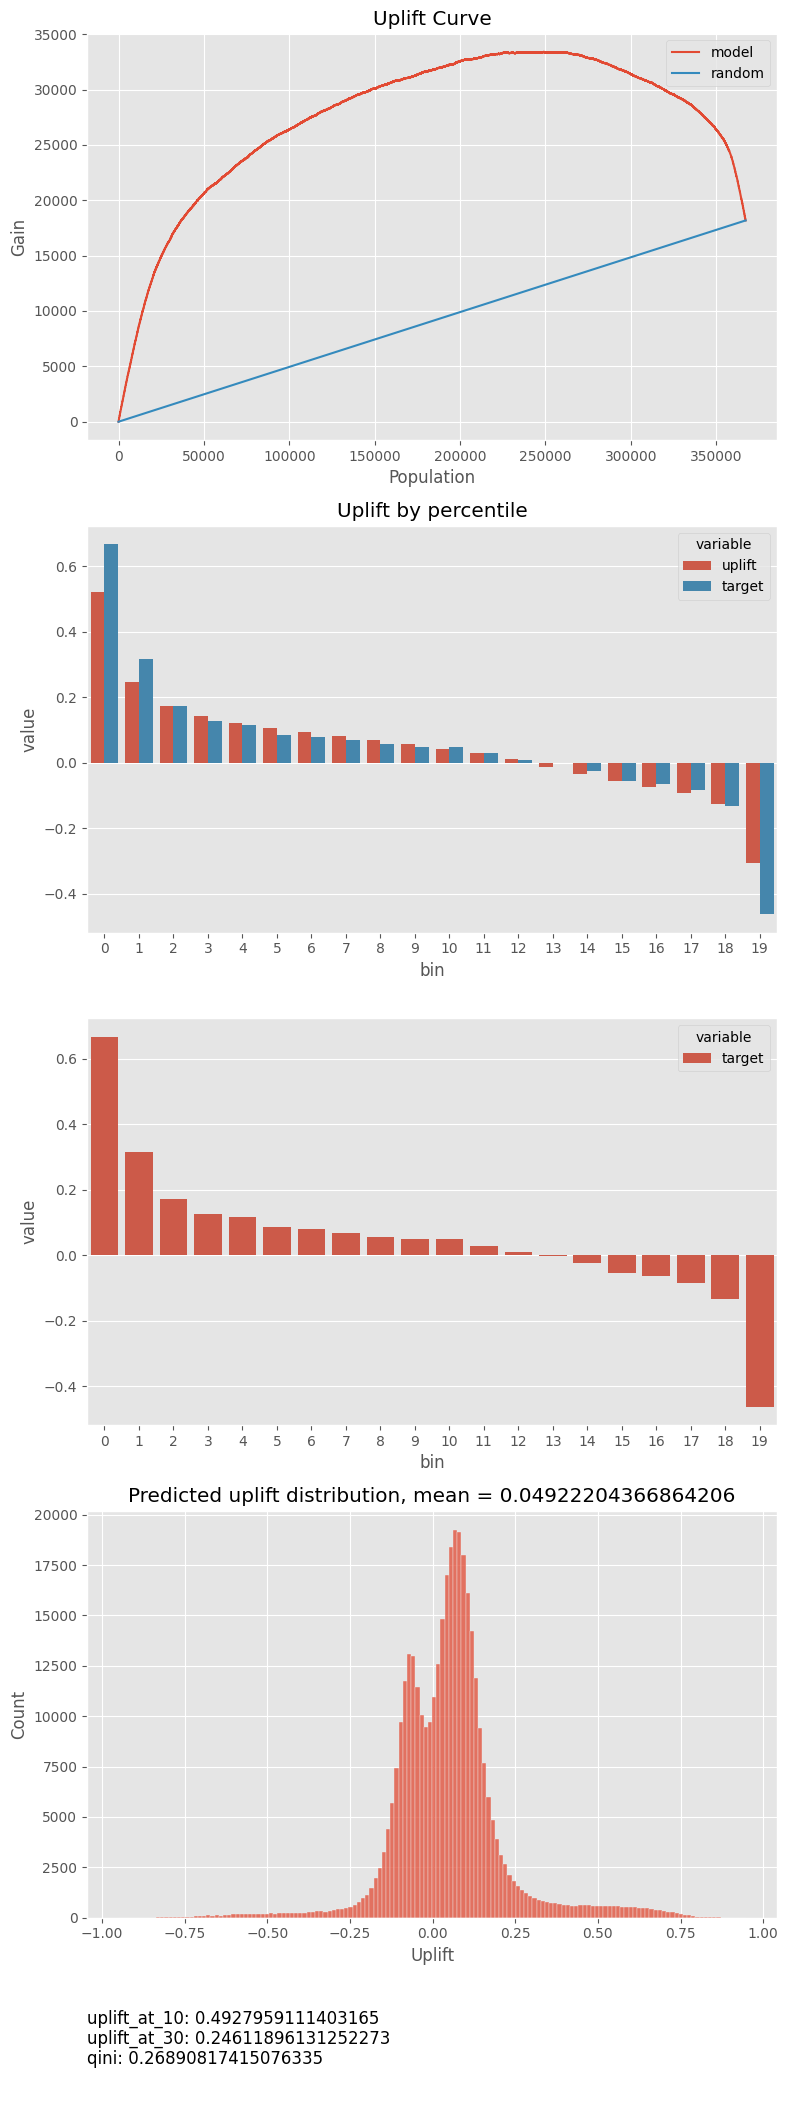

[2026-09-03 13:47:50,845] - [matplotlib.category] - [INFO] - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[2026-09-03 13:47:50,847] - [matplotlib.category] - [INFO] - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[2026-09-03 13:47:50,885] - [matplotlib.category] - [INFO] - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[2026-09-03 13:47:50,887] - [matplotlib.category] - [INFO] - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotti

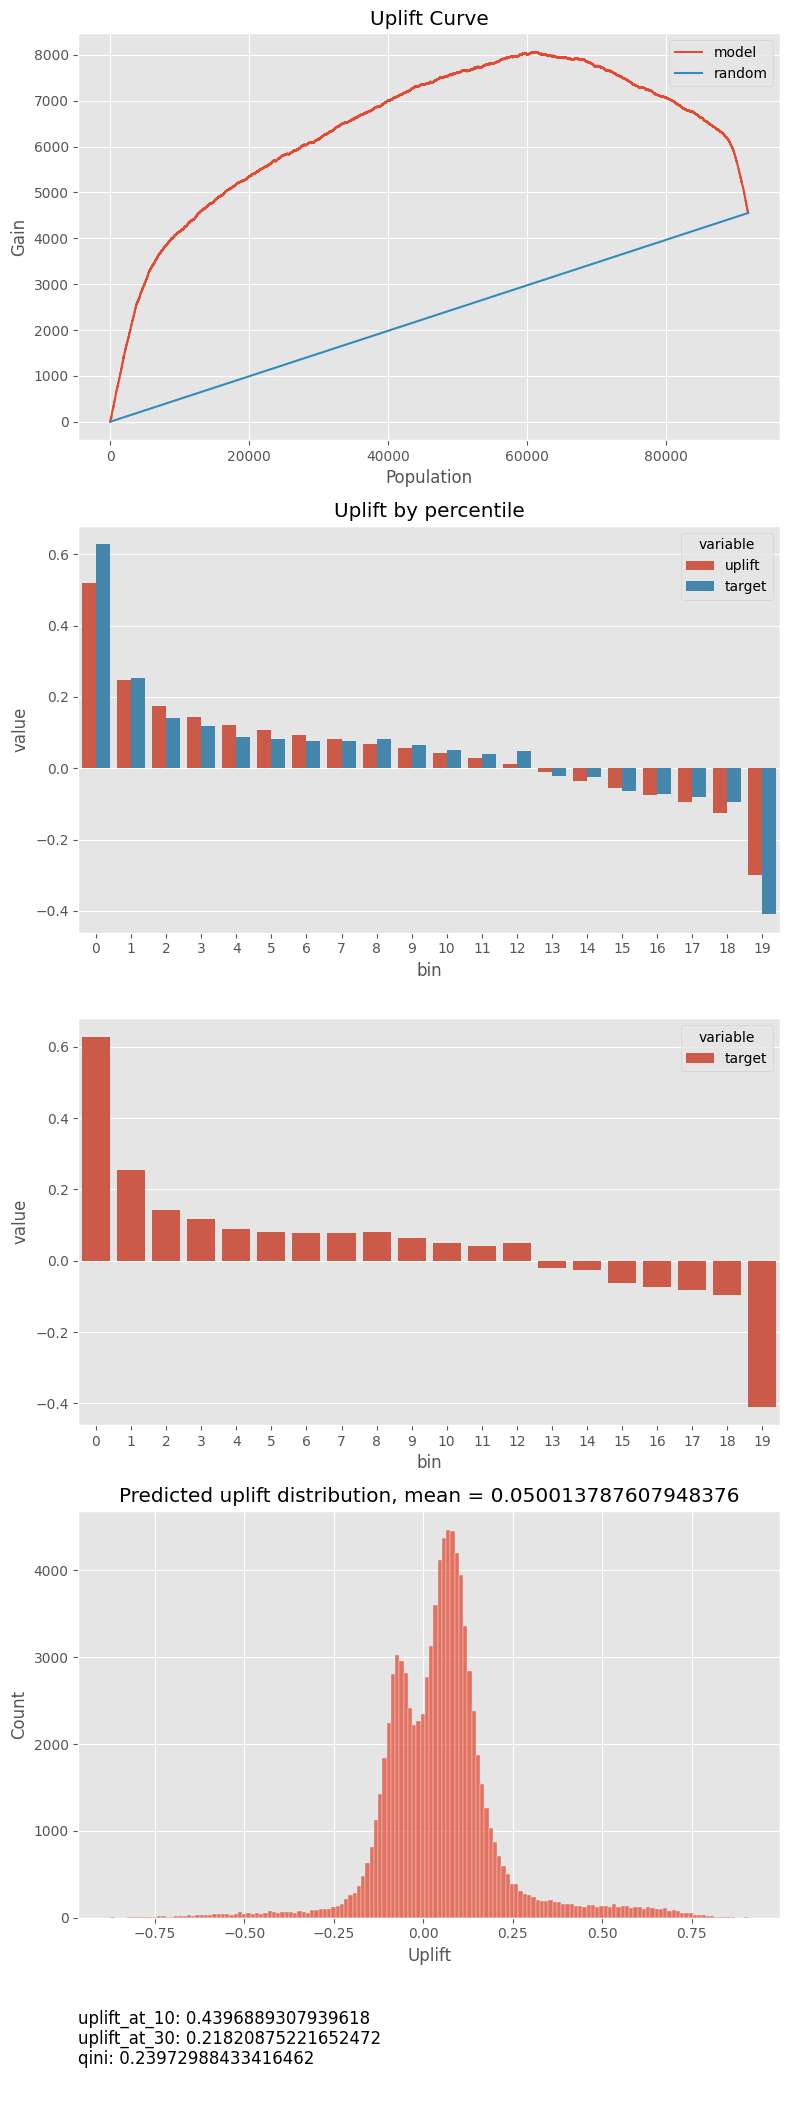

In [25]:
if config.general.select_features:
    _logger.info('Обучаем модель на всех признаках')
    train_dataset = dataset_pd_sample_prep

    train, val = train_test_split(
        train_dataset,
        test_size=0.2,
        shuffle=True,
        stratify=train_dataset[[config.dataset.date_col, config.dataset.target_col, config.dataset.treatment_col]],
        random_state=config.general.seed
    )

    model = CatBoostClassifier(iterations=700, verbose=False, random_state=config.general.seed)
    model.fit(train.drop([config.dataset.date_col, config.dataset.target_col], axis=1), train[config.dataset.target_col])

    preds_train = model.predict_proba(train.drop([config.dataset.date_col, config.dataset.target_col], axis=1))[:, 1]
    preds_val = model.predict_proba(val.drop([config.dataset.date_col, config.dataset.target_col], axis=1))[:, 1]

    _logger.info(f'Train roc_auc: {roc_auc_score(train[config.dataset.target_col], preds_train)}')
    _logger.info(f'Val roc_auc: {roc_auc_score(val[config.dataset.target_col], preds_val)}')

    imps = model.get_feature_importance(prettified=True)
    _logger.info(f"Число признаков с 0 feature importance: {imps[imps['Importances'] == 0].shape[0]}")

    display(imps.head(15))

    uplift_train = (
        model.predict_proba(
            train.drop([config.dataset.date_col, config.dataset.target_col], axis=1)
            .assign(**{config.dataset.treatment_col: np.ones(shape=(train.shape[0], 1))}))[:, 1]
        - model.predict_proba(
            train.drop([config.dataset.date_col, config.dataset.target_col], axis=1)
            .assign(**{config.dataset.treatment_col: np.zeros(shape=(train.shape[0], 1))}))[:, 1]
    )

    uplift_val = (
        model.predict_proba(
            val.drop([config.dataset.date_col, config.dataset.target_col], axis=1)
            .assign(**{config.dataset.treatment_col: np.ones(shape=(val.shape[0], 1))}))[:, 1]
        
        - model.predict_proba(
            val.drop([config.dataset.date_col, config.dataset.target_col], axis=1)
            .assign(**{config.dataset.treatment_col: np.zeros(shape=(val.shape[0], 1))}))[:, 1]
    )

    show_results(
        train[config.dataset.target_col].values.ravel(),
        uplift_train,
        train[config.dataset.treatment_col].values.ravel(),
        save=True,
        save_path=fs_path,
        save_prefix='train_all_features'
    )

    show_results(
        val[config.dataset.target_col].values.ravel(),
        uplift_val,
        val[config.dataset.treatment_col].values.ravel(),
        save=True,
        save_path=fs_path,
        save_prefix='val_all_features'
    )

    del train_dataset, train, val, model, preds_train, preds_val, uplift_train, uplift_val

## PSI

In [26]:
if config.general.select_features:
    dataset_pd_sample_prep['split_col'] = 0

    dates = sorted(dataset_pd_sample_prep[config.dataset.date_col].unique())
    slice_size = len(dates) // 4

    for i in range(1, 4):
        split_date = dates[i*slice_size]
        dataset_pd_sample_prep.loc[dataset_pd_sample_prep[config.dataset.date_col] < split_date, 'split_col'] += 1

In [27]:
if config.general.select_features:
    def calculate_psi_for_splits(df, date_column, dates, features_list, SEED=config.general.seed):
        results = list()

        for i, first_date in enumerate(dates):
            for second_date in dates[i+1:]:
                print(f'FIRST_DATE: {first_date}, SECOND_DATE: {second_date}')

                expected = df[df[date_column] == first_date][features_list].copy()
                actual = df[df[date_column] == second_date][features_list].copy()

                psi_score = calculate_psi(expected, actual)
                psi_score.rename(columns={'psi': f'psi_{first_date}_{second_date}'}, inplace=True)
                results.append(psi_score)

        res = results[0]
        for res2 in results[1:]:
            res = res.merge(res2, on='feature')

        res['psi_mean'] = res[[col for col in res.columns if col != 'feature']].mean(axis=1)

        res['is_unstable'] = 0
        res.loc[res['psi_mean'] >= 0.25, 'is_unstable'] = 2
        res.loc[(res['psi_mean'] >= 0.1) & (res['psi_mean'] < 0.25), 'is_unstable'] = 1
        return res

In [28]:
if config.general.select_features:
    dates = sorted(dataset_pd_sample_prep['split_col'].unique())
    psi_results = calculate_psi_for_splits(
        dataset_pd_sample_prep,
        'split_col',
        dates,
        [col for col in dataset_pd_sample_prep.columns.tolist() if col not in
        [config.dataset.date_col, config.dataset.target_col, config.dataset.treatment_col, 'split_col']
        ]
    )

FIRST_DATE: 0, SECOND_DATE: 1
FIRST_DATE: 0, SECOND_DATE: 2
FIRST_DATE: 0, SECOND_DATE: 3
FIRST_DATE: 1, SECOND_DATE: 2
FIRST_DATE: 1, SECOND_DATE: 3
FIRST_DATE: 2, SECOND_DATE: 3


In [29]:
if config.general.select_features:
    def style_rows(row):
        soft_green = '#7cfc00'
        soft_yellow = '#ffcf48'
        soft_red = '#e32636'

        color_map = {0: soft_green, 1: soft_yellow, 2: soft_red}
        color = color_map.get(row['is_unstable'], '')
        return [f'background-color: {color}' for _ in row]

    styled_psi_results = psi_results.style.apply(style_rows, axis=1)
    styled_psi_results.to_html(fs_path / 'psi.html')

    _logger.info(f"PSI по признакам сохранены в {fs_path / 'psi.html'}")

[2026-09-03 13:47:56,368] - [feature_selection] - [INFO] - PSI по признакам сохранены в /Users/romansafronenkov/Documents/Projects/uplift_modeling_pipeline/artifacts/boosting_pipeline/feature_selection/psi.html


In [30]:
if config.general.select_features:
    candidates = psi_results[psi_results['is_unstable'] != 2]['feature'].tolist()
    with open(fs_path / 'candidates.json', 'w') as f:
        json.dump(candidates, f)

## Отбор признаков с помощью LightGBM и Shap

In [31]:
if config.general.select_features:
    with open(fs_path / 'candidates.json', 'r') as f:
        candidates = json.load(f)

    dataset_pd_sample_prep = dataset_pd_sample_prep.reset_index(drop=True)

    kfold = StratifiedKFold(n_splits=4, shuffle=True, random_state=config.general.seed)

In [32]:
if config.general.select_features:
    _logger.info('Treatment')
    x = dataset_pd_sample_prep[dataset_pd_sample_prep[config.dataset.treatment_col] == 1][candidates]
    y = dataset_pd_sample_prep[dataset_pd_sample_prep[config.dataset.treatment_col] == 1][config.dataset.target_col]

    _logger.info('Fitting LGM for treatment')
    t_lgm_fs = LGMFeatureSelection(n_folds=4, random_state=config.general.seed)

    t_lgm_fs.fit(x=x.values, y=y.values, columns=x.columns.tolist(), skf=kfold)
    t_lgm_fs.importances.to_csv(fs_path / 't_lgm_fs_imps.csv', index=False)
    t_lgm_fs.importances = pd.read_csv(fs_path / 't_lgm_fs_imps.csv')

    _logger.info('Fitting Shap for treatment')
    t_shap_fs = ShapFeatureSelection(n_folds=4, random_state=config.general.seed)

    t_shap_fs.fit(x=x.values, y=y.values, columns=x.columns.tolist(), skf=kfold)
    t_shap_fs.importances.to_csv(fs_path / 't_shap_fs_imps.csv', index=False)
    t_shap_fs.importances = pd.read_csv(fs_path / 't_shap_fs_imps.csv')

    _logger.info('Control')
    x = dataset_pd_sample_prep[dataset_pd_sample_prep[config.dataset.treatment_col] == 0][candidates]
    y = dataset_pd_sample_prep[dataset_pd_sample_prep[config.dataset.treatment_col] == 0][config.dataset.target_col]

    _logger.info('Fitting LGM for control')
    c_lgm_fs = LGMFeatureSelection(n_folds=4, random_state=config.general.seed)

    c_lgm_fs.fit(x=x.values, y=y.values, columns=x.columns.tolist(), skf=kfold)
    c_lgm_fs.importances.to_csv(fs_path / 'c_lgm_fs_imps.csv', index=False)
    c_lgm_fs.importances = pd.read_csv(fs_path / 'c_lgm_fs_imps.csv')

    _logger.info('Fitting Shap for control')
    c_shap_fs = ShapFeatureSelection(n_folds=4, random_state=config.general.seed)

    c_shap_fs.fit(x=x.values, y=y.values, columns=x.columns.tolist(), skf=kfold)
    c_shap_fs.importances.to_csv(fs_path / 'c_shap_fs_imps.csv', index=False)
    c_shap_fs.importances = pd.read_csv(fs_path / 'c_shap_fs_imps.csv')

    selected = list((set(t_lgm_fs.get_selected_features(0.85)) & set(t_shap_fs.get_selected_features(0.85))) \
                    | (set(c_lgm_fs.get_selected_features(0.85)) & set(c_shap_fs.get_selected_features(0.85))))

    _logger.info(f'Число отобранных признаков: {len(selected)}')

    with open(fs_path / 'features_selected_lgm_shap_raw.json', 'w') as f:
        json.dump(selected, f)

    clear_output()
    _logger.info(f'Признаки сохранены в {fs_path / "features_selected_lgm_shap_raw.json"}')

[2026-09-03 14:18:42,363] - [feature_selection] - [INFO] - Признаки сохранены в /Users/romansafronenkov/Documents/Projects/uplift_modeling_pipeline/artifacts/boosting_pipeline/feature_selection/features_selected_lgm_shap_raw.json


## Проверим стабильность признаков

In [33]:
if config.general.select_features:
    def check_feature_stability(df, date_column, dates, features_list, SEED=config.general.seed):
        results = {}
        combs = []

        for i, first_date in enumerate(dates):
            for second_date in dates[i+1:]:
                print(f'FIRST_DATE: {first_date}, SECOND_DATE: {second_date}')
                combs.append((first_date, second_date))

                for feature in tqdm(features_list, position=0):
                    if feature not in results.keys():
                        results[feature] = []

                    check_df = df[df[date_column].isin([first_date, second_date])][[date_column, feature]].copy()
                    check_df['target'] = (check_df[date_column] == second_date).astype(int)

                    x_train, x_test, y_train, y_test = train_test_split(
                        check_df[[feature]], check_df['target'], test_size=0.33, random_state=SEED)

                    try:
                        estimator = CatBoostClassifier(
                            n_estimators=500, max_depth=5, eval_fraction=0.2, od_wait=15, random_state=SEED, verbose=False)
                        estimator.fit(x_train, y_train)

                        preds = estimator.predict_proba(x_test)[:, 1]

                        score = roc_auc_score(y_test, preds)
                        results[feature].append(score)
                    except CatBoostError as e:
                        print(f'Feature: {feature}\n{e}')
                        results[feature].append(0.5)
        return results, combs

In [34]:
if config.general.select_features:
    dataset_pd_sample_prep['split_col'] = 0

    dates = sorted(dataset_pd_sample_prep[config.dataset.date_col].unique())
    slice_size = len(dates) // 4

    for i in range(1, 4):
        split_date = dates[i*slice_size]
        dataset_pd_sample_prep.loc[dataset_pd_sample_prep[config.dataset.date_col] < split_date, 'split_col'] += 1

    dates = sorted(dataset_pd_sample_prep['split_col'].unique())
    stability_results, stability_combs = check_feature_stability(dataset_pd_sample_prep, 'split_col', dates, selected, config.general.seed)

    joblib.dump(stability_results, fs_path / 'feature_stability_results.pkl')
    joblib.dump(stability_combs, fs_path / 'feature_stability_combs.pkl')

    dataset_pd_sample_prep.drop(columns=['split_col'], inplace=True)

FIRST_DATE: 0, SECOND_DATE: 1


100%|███████████████████████████████████████████| 25/25 [00:09<00:00,  2.50it/s]


FIRST_DATE: 0, SECOND_DATE: 2


100%|███████████████████████████████████████████| 25/25 [00:10<00:00,  2.47it/s]


FIRST_DATE: 0, SECOND_DATE: 3


...

100%|███████████████████████████████████████████| 25/25 [00:04<00:00,  5.74it/s]


FIRST_DATE: 1, SECOND_DATE: 3


100%|███████████████████████████████████████████| 25/25 [00:04<00:00,  5.33it/s]


FIRST_DATE: 2, SECOND_DATE: 3


100%|███████████████████████████████████████████| 25/25 [00:04<00:00,  5.42it/s]


In [35]:
if config.general.select_features:
    stability_results = joblib.load(fs_path / 'feature_stability_results.pkl')

    stability_results = pd.DataFrame(stability_results)
    mean_results = stability_results.mean()
    selected = mean_results[mean_results < 0.6].index.tolist()

In [36]:
if config.general.select_features:
    display(mean_results[mean_results > 0.6])

Series([], dtype: float64)

In [37]:
if config.general.select_features:
    with open(fs_path / 'features_selected_lgm_shap.json', 'w') as f:
        json.dump(selected, f)

    _logger.info(f'Стабильные признаки сохранены в {fs_path / "features_selected_lgm_shap.json"}')
    _logger.info(f'Число признаков на этом этапе: {len(selected)}')

[2026-09-03 14:19:25,629] - [feature_selection] - [INFO] - Стабильные признаки сохранены в /Users/romansafronenkov/Documents/Projects/uplift_modeling_pipeline/artifacts/boosting_pipeline/feature_selection/features_selected_lgm_shap.json
[2026-09-03 14:19:25,630] - [feature_selection] - [INFO] - Число признаков на этом этапе: 25


## BorutaShap

In [40]:
if config.general.select_features:
    def fit_lgm_params(x_train: np.ndarray, y_train: np.ndarray,
                      x_val: np.ndarray, y_val: np.ndarray):
        print('Fitting params')
        def objective(trial):
            params = {
                'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
                'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
                'num_leaves': trial.suggest_int('num_leaves', 2, 256),
                'max_depth': trial.suggest_int('max_depth', 2, 8),
                'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.5),
                'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 1.0),
                'bagging_fraction': trial.suggest_float('bagging_fraction', 0.4, 1.0),
                'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
                'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
                'class_weight': trial.suggest_categorical('class_weight', ['balanced', None]),
                'verbose': -100,
                'random_state': config.general.seed
            }

            model = LGBMClassifier(**params)
            model.fit(x_train, y_train, eval_set=(x_val, y_val), callbacks=[early_stopping(stopping_rounds=30)])

            preds_train = model.predict_proba(x_train)[:, 1]
            preds_val = model.predict_proba(x_val)[:, 1]

            metric_train = roc_auc_score(y_train, preds_train)
            metric_val = roc_auc_score(y_val, preds_val)

            metric = metric_stability(metric_train, metric_val, 0.2)

            print(f'Trial #{trial.number}. Metric: {metric}. Params: {trial.params}')
            return metric

        study = optuna.create_study(
            direction='maximize',
            sampler=optuna.samplers.TPESampler(n_startup_trials=10, multivariate=True)
        )

        study.optimize(objective, n_trials=30, n_jobs=1)
        params = study.best_params
        params['verbose'] = -100
        params['random_state'] = config.general.seed

        return params

In [41]:
if config.general.select_features:
    np.NaN = np.nan
    
    _logger.info('Обучим BorutaShap для treatment')
    x = dataset_pd_sample_prep[dataset_pd_sample_prep[config.dataset.treatment_col] == 1][selected]
    y = dataset_pd_sample_prep[dataset_pd_sample_prep[config.dataset.treatment_col] == 1][config.dataset.target_col]

    x_train, x_val, y_train, y_val = train_test_split(
        x,
        y,
        test_size=0.2,
        shuffle=True,
        stratify=(dataset_pd_sample_prep[dataset_pd_sample_prep[config.dataset.treatment_col] == 1]
                  [[config.dataset.date_col, config.dataset.treatment_col, config.dataset.target_col]]),
        random_state=config.general.seed
    )

    params = fit_lgm_params(x_train, y_train, x_val, y_val)
    model = LGBMClassifier(**params)

    boruta_fs = BorutaShap(model=model, importance_measure='shap', classification=True)
    boruta_fs.fit(X=x, y=y, n_trials=50, random_state=config.general.seed)
    joblib.dump(boruta_fs, fs_path / 't_boruta_fs.pkl')

    _logger.info('Обучим BorutaShap для control')
    x = dataset_pd_sample_prep[dataset_pd_sample_prep[config.dataset.treatment_col] == 0][selected]
    y = dataset_pd_sample_prep[dataset_pd_sample_prep[config.dataset.treatment_col] == 0][config.dataset.target_col]

    x_train, x_val, y_train, y_val = train_test_split(
        x,
        y,
        test_size=0.2,
        shuffle=True,
        stratify=(dataset_pd_sample_prep[dataset_pd_sample_prep[config.dataset.treatment_col] == 0]
                  [[config.dataset.date_col, config.dataset.treatment_col, config.dataset.target_col]]),
        random_state=config.general.seed
    )

    params = fit_lgm_params(x_train, y_train, x_val, y_val)
    model = LGBMClassifier(**params)

    boruta_fs = BorutaShap(model=model, importance_measure='shap', classification=True)
    boruta_fs.fit(X=x, y=y, n_trials=50, random_state=config.general.seed)
    joblib.dump(boruta_fs, fs_path / 'c_boruta_fs.pkl')

    _logger.info('Сохраним итоговые признаки')
    t_boruta_fs = joblib.load(fs_path / 't_boruta_fs.pkl')
    t_boruta_fs.TentativeRoughFix()

    selected_tr = list(set(t_boruta_fs.accepted))

    c_boruta_fs = joblib.load(fs_path / 'c_boruta_fs.pkl')
    c_boruta_fs.TentativeRoughFix()

    selected_c = list(set(c_boruta_fs.accepted))
    selected = list(set(selected_tr + selected_c))

    with open(fs_path / 'features_selected_final.json', 'w') as f:
        json.dump(selected, f)

    clear_output()
    _logger.info(f'Финальные признаки сохранены в {fs_path / "features_selected_final.json"}')
    _logger.info(f'Итоговое число признаков: {len(selected)}')

[2026-09-05 10:04:23,148] - [feature_selection] - [INFO] - Финальные признаки сохранены в /Users/romansafronenkov/Documents/Projects/uplift_modeling_pipeline/artifacts/boosting_pipeline/feature_selection/features_selected_final.json
[2026-09-05 10:04:23,149] - [feature_selection] - [INFO] - Итоговое число признаков: 25


In [42]:
with open(project_root / 'artifacts' / config.general.experiment_name / 'status.json', 'w') as f:
    status = {
        'init': True,
        'dataset': True,
        'features': True,
        'choose_model': False,
        'optimization': False,
        'fitting': False
    }
    json.dump(status, f)

In [ ]:
os._exit(00)